In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Load the dataset
df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749')

## **1. Basic Data Exploration**

In [5]:
# --- 1. Basic Data Exploration ---
print("Shape of dataset:", df.shape)
print("\nData Types:\n", df.dtypes)

# Convert categorical columns to 'category' dtype
cat_cols = ['Product', 'Gender', 'MaritalStatus']
for col in cat_cols:
    df[col] = df[col].astype('category')

print("\nCategorical columns converted to 'category' dtype")

Shape of dataset: (180, 9)

Data Types:
 Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object

Categorical columns converted to 'category' dtype


In [6]:
# Statistical summary of numeric columns
print("\nStatistical Summary:\n", df.describe())

# Check for missing values
print("\nMissing values per column:\n", df.isnull().sum())


Statistical Summary:
               Age   Education       Usage     Fitness         Income  \
count  180.000000  180.000000  180.000000  180.000000     180.000000   
mean    28.788889   15.572222    3.455556    3.311111   53719.577778   
std      6.943498    1.617055    1.084797    0.958869   16506.684226   
min     18.000000   12.000000    2.000000    1.000000   29562.000000   
25%     24.000000   14.000000    3.000000    3.000000   44058.750000   
50%     26.000000   16.000000    3.000000    3.000000   50596.500000   
75%     33.000000   16.000000    4.000000    4.000000   58668.000000   
max     50.000000   21.000000    7.000000    5.000000  104581.000000   

            Miles  
count  180.000000  
mean   103.194444  
std     51.863605  
min     21.000000  
25%     66.000000  
50%     94.000000  
75%    114.750000  
max    360.000000  

Missing values per column:
 Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitne

## **2. Detect Outliers using boxplots and compare mean vs median for numeric variables**

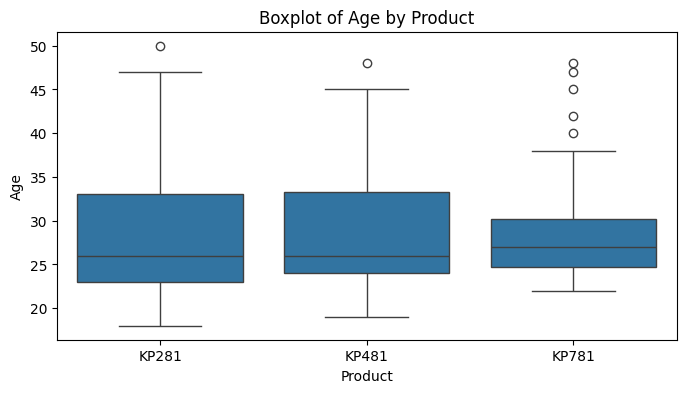

Age - Mean: 28.79, Median: 26.00


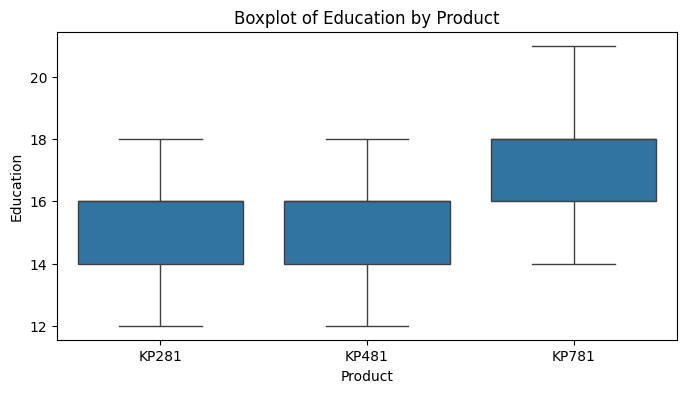

Education - Mean: 15.57, Median: 16.00


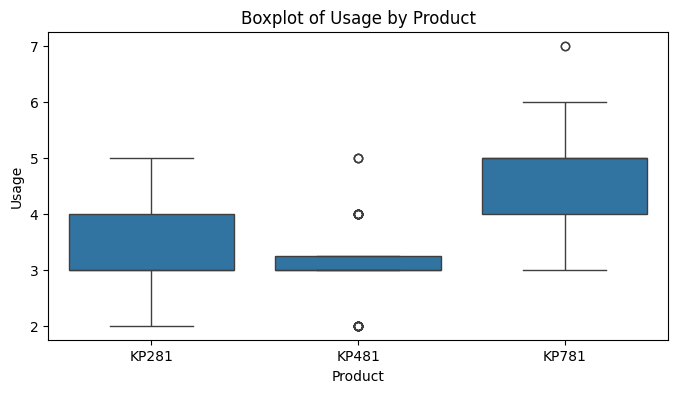

Usage - Mean: 3.46, Median: 3.00


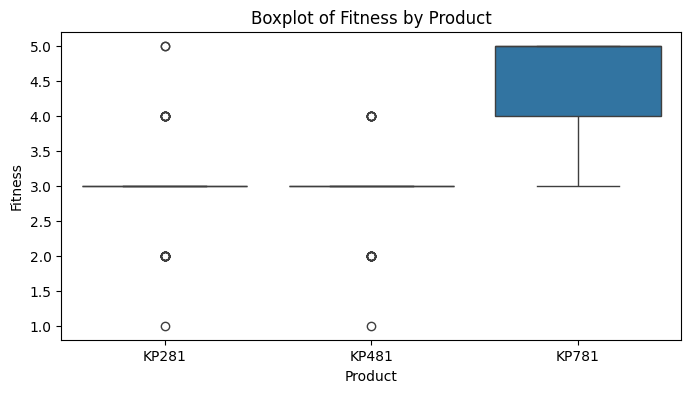

Fitness - Mean: 3.31, Median: 3.00


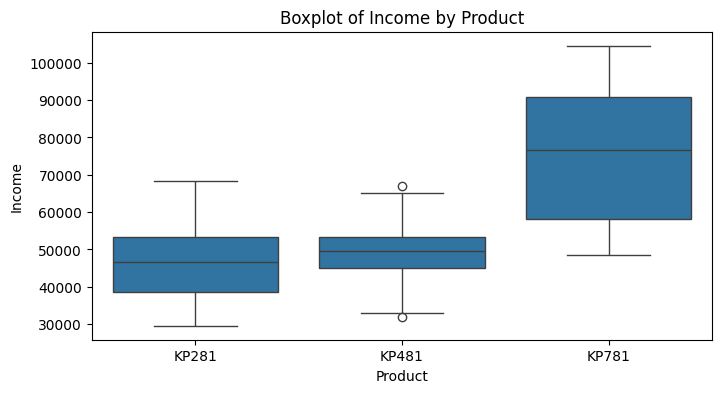

Income - Mean: 53719.58, Median: 50596.50


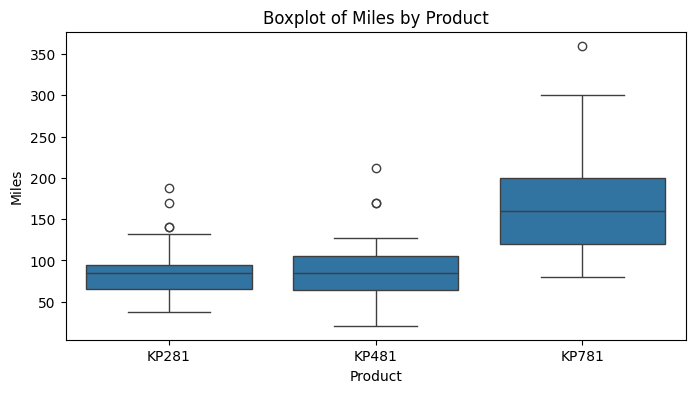

Miles - Mean: 103.19, Median: 94.00


In [7]:
# --- 2. Detect Outliers using boxplots and compare mean vs median for numeric variables ---
numeric_cols = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Product', y=col, data=df)
    plt.title(f'Boxplot of {col} by Product')
    plt.show()

    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col} - Mean: {mean_val:.2f}, Median: {median_val:.2f}")

## **3. Effect of categorical variables 'MaritalStatus' & 'Age' on Product Purchased**

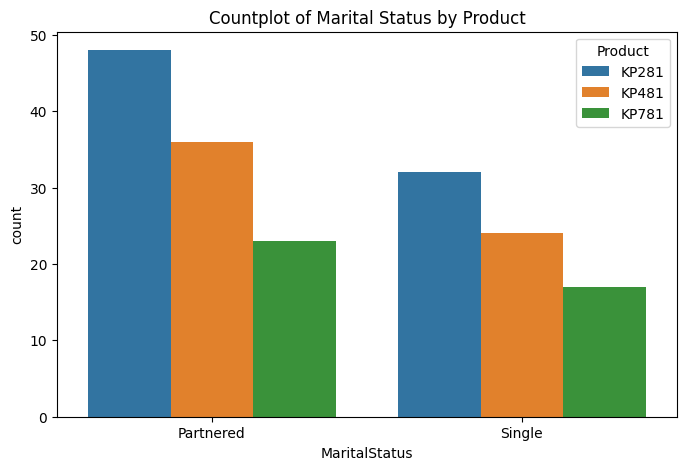

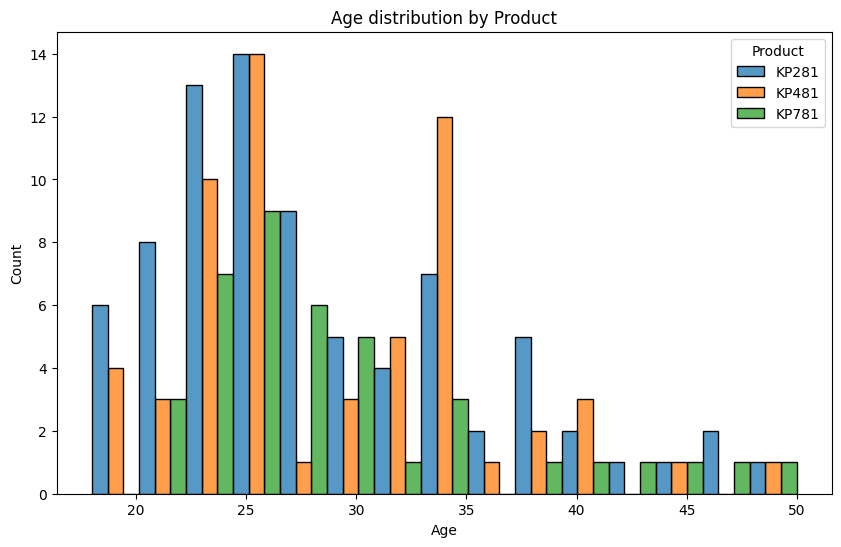

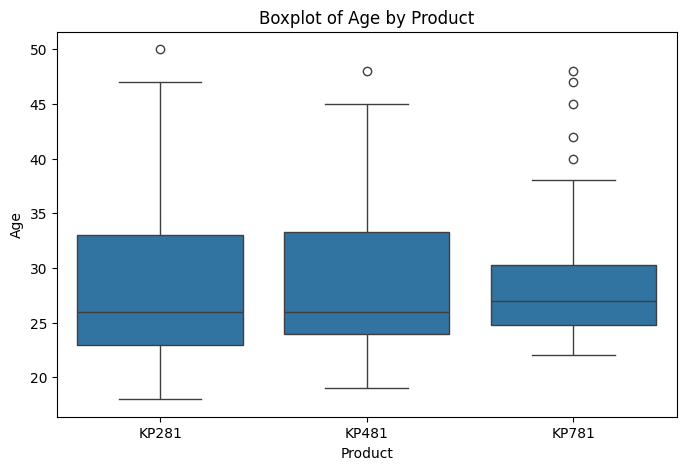

In [8]:
# --- 3. Effect of categorical variables 'MaritalStatus' & 'Age' on Product Purchased ---
plt.figure(figsize=(8, 5))
sns.countplot(x='MaritalStatus', hue='Product', data=df)
plt.title("Countplot of Marital Status by Product")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Product', multiple='dodge', bins=15, kde=False)
plt.title("Age distribution by Product")
plt.show()

# Boxplot of Age by Product
plt.figure(figsize=(8, 5))
sns.boxplot(x='Product', y='Age', data=df)
plt.title("Boxplot of Age by Product")
plt.show()

## **4. Marginal probability of product purchased**

In [9]:
# --- 4. Marginal probability of product purchased ---
product_counts = df['Product'].value_counts(normalize=True).rename_axis('Product').reset_index(name='Marginal Probability')
print("\nMarginal Probability of Product Purchased:\n", product_counts)

# Using pandas crosstab for contingencies
product_gender_ct = pd.crosstab(df['Product'], df['Gender'], normalize='index')
print("\nConditional Probability P(Gender|Product):\n", product_gender_ct)

# Probability of Male customer buying KP781
p_product = product_counts.set_index('Product')
p_male_given_kp781 = product_gender_ct.loc['KP781','Male']
print(f"\nProbability of Male customer given KP781 purchased: {p_male_given_kp781:.3f}")



Marginal Probability of Product Purchased:
   Product  Marginal Probability
0   KP281              0.444444
1   KP481              0.333333
2   KP781              0.222222

Conditional Probability P(Gender|Product):
 Gender     Female      Male
Product                    
KP281    0.500000  0.500000
KP481    0.483333  0.516667
KP781    0.175000  0.825000

Probability of Male customer given KP781 purchased: 0.825


## **5. Correlation analysis**

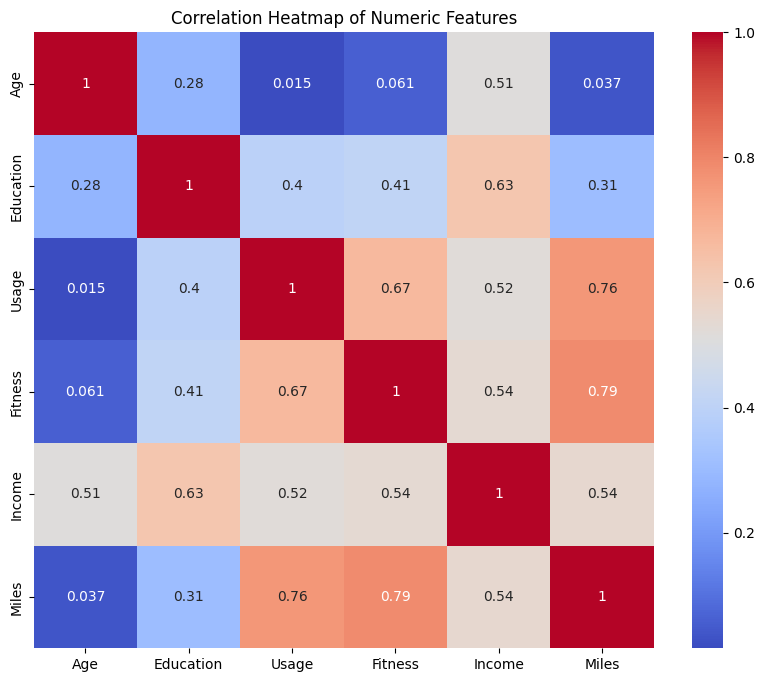

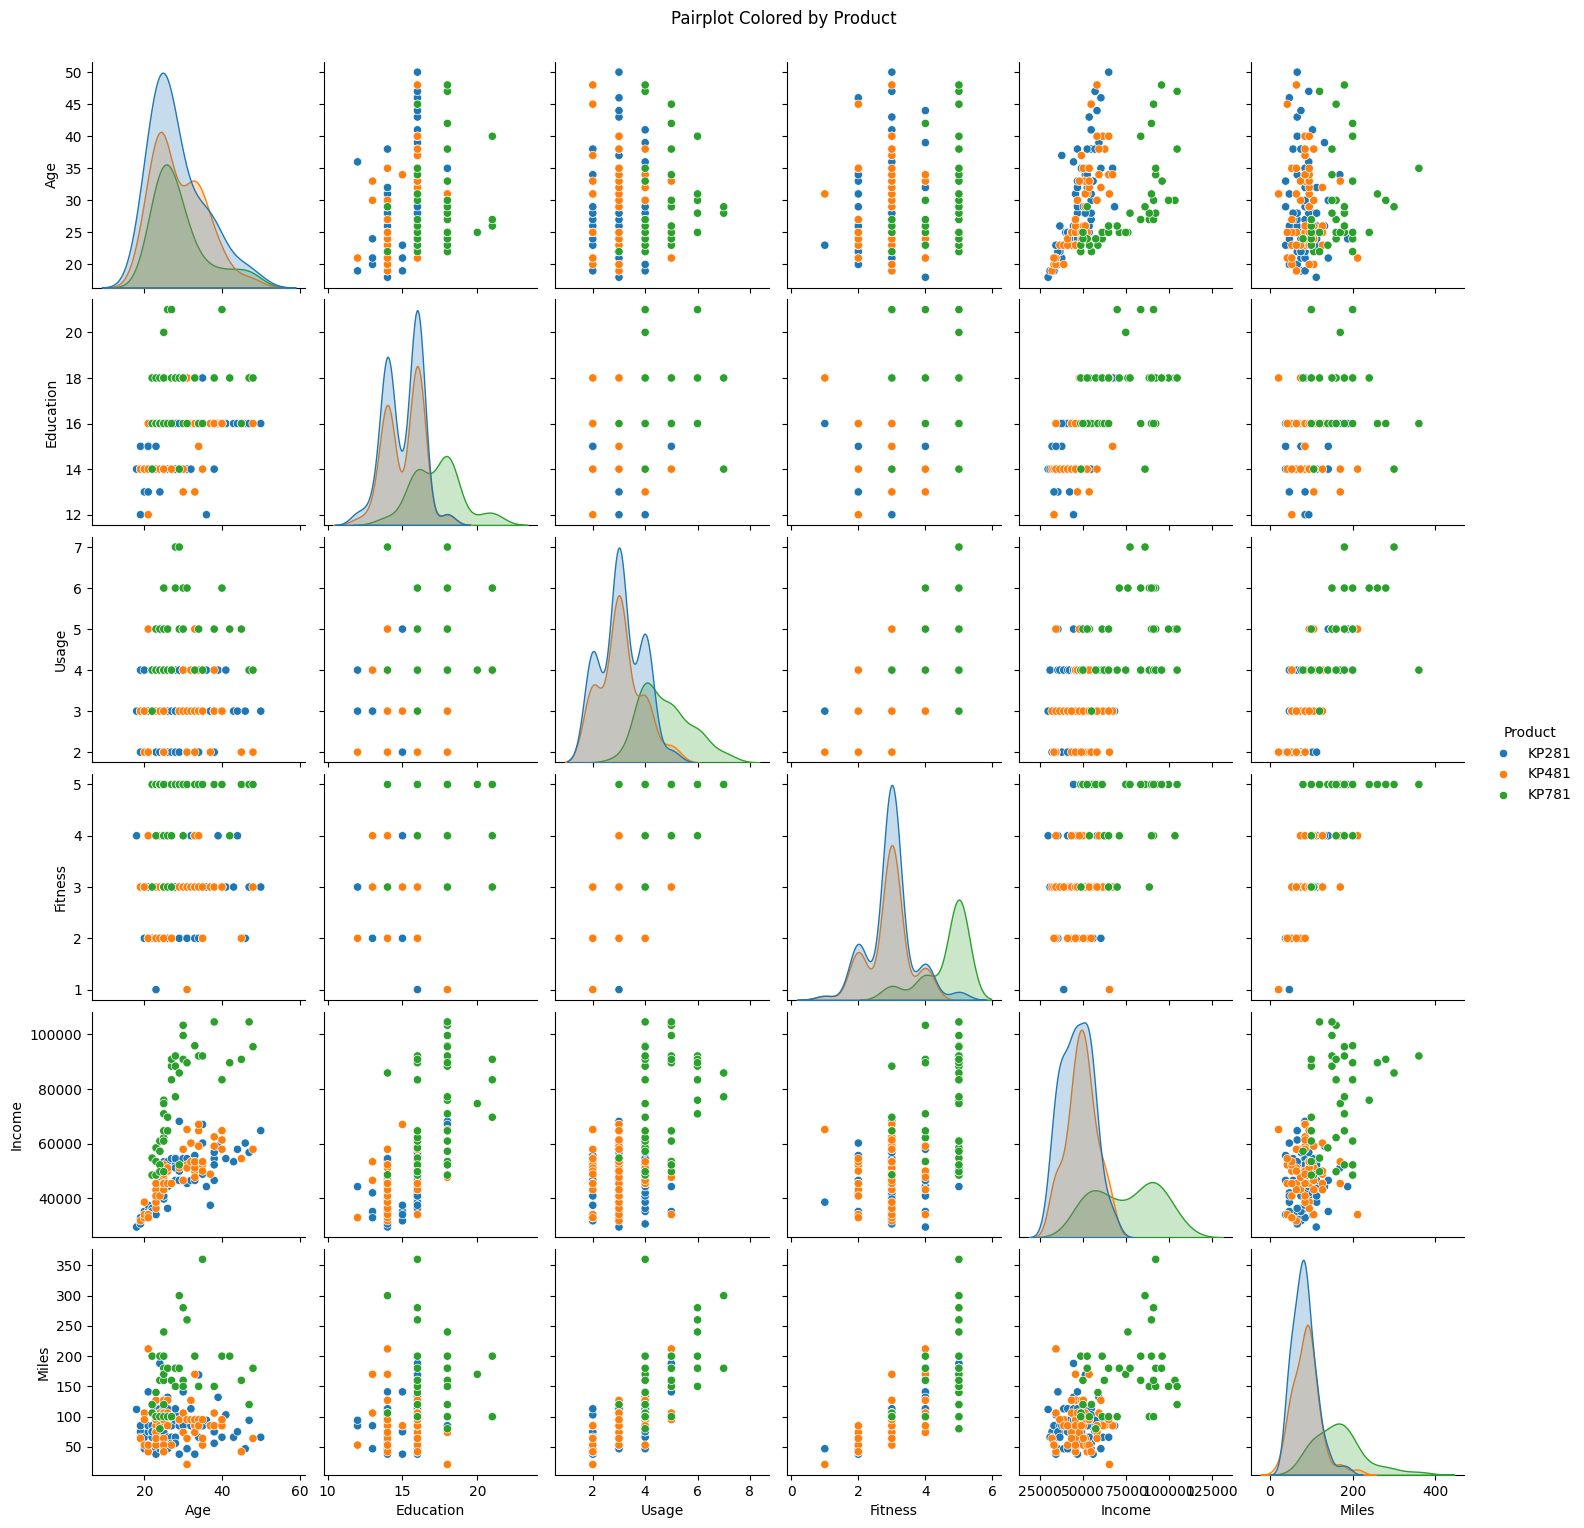

In [10]:
# --- 5. Correlation analysis ---
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

sns.pairplot(df, hue='Product', vars=numeric_cols)
plt.suptitle("Pairplot Colored by Product", y=1.02)
plt.show()

## **6. Two-way contingency tables & probabilities**

In [11]:
# --- 6. Two-way contingency tables & probabilities ---
# Product vs Gender
ct_product_gender = pd.crosstab(df['Product'], df['Gender'])
print("\nContingency Table: Product vs Gender\n", ct_product_gender)

# Marginal probabilities
marginal_product = ct_product_gender.sum(axis=1) / ct_product_gender.values.sum()
marginal_gender = ct_product_gender.sum(axis=0) / ct_product_gender.values.sum()

# Conditional probability P(Gender|Product)
cond_gender_given_product = ct_product_gender.div(ct_product_gender.sum(axis=1), axis=0)
print("\nConditional Probability P(Gender|Product):\n", cond_gender_given_product)

# Similarly Product vs MaritalStatus
ct_product_marital = pd.crosstab(df['Product'], df['MaritalStatus'])
print("\nContingency Table: Product vs MaritalStatus\n", ct_product_marital)

cond_marital_given_product = ct_product_marital.div(ct_product_marital.sum(axis=1), axis=0)
print("\nConditional Probability P(MaritalStatus|Product):\n", cond_marital_given_product)



Contingency Table: Product vs Gender
 Gender   Female  Male
Product              
KP281        40    40
KP481        29    31
KP781         7    33

Conditional Probability P(Gender|Product):
 Gender     Female      Male
Product                    
KP281    0.500000  0.500000
KP481    0.483333  0.516667
KP781    0.175000  0.825000

Contingency Table: Product vs MaritalStatus
 MaritalStatus  Partnered  Single
Product                         
KP281                 48      32
KP481                 36      24
KP781                 23      17

Conditional Probability P(MaritalStatus|Product):
 MaritalStatus  Partnered  Single
Product                         
KP281              0.600   0.400
KP481              0.600   0.400
KP781              0.575   0.425


## **7. Insights / Business Impact**


### **Business Insights:**
- KP281 customers tend to be younger, mostly single, and have lower income compared to KP481 and KP781.
- The KP781, being the premium model, attracts customers with higher income, typically partnered and male.
- Male customers have a higher probability of buying KP781.
- Usage frequency and fitness levels slightly increase with product sophistication.
- Higher education correlates with premium product purchases.
- Younger unmarried customers prefer entry-level KP281, while more experienced users opt for advanced models.
- Correlations indicate that income and miles exercised per week positively correlate with product level, suggesting fitness-conscious affluent customers prefer advanced treadmills.

### **Recommendations:**
- Market KP781 heavily to male, partnered, higher-income customers with higher fitness levels.
- Consider promotional offers for KP281 focusing on younger, single customers with moderate income.
- Create targeted campaigns highlighting features aligned with customer fitness and usage patterns.
- Use these profiles to refine personalized recommendations and improve customer satisfaction.
